In [2]:
# Install Required Libraries
!pip install scikit-learn scikit-optimize

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 4.5 MB/s eta 0:00:00


In [12]:
# Import Libraries
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from skopt import BayesSearchCV
from skopt.space import Integer, Real
import matplotlib.pyplot as plt

In [4]:
# Load and Preprocess Data
# Load the dataset
data = pd.read_csv('/content/Final_Cleaned_Voyage_Data.csv', parse_dates=['DepartureTime', 'ArrivalTime'], infer_datetime_format=True)

# Convert datetimes and calculate duration
data['DepartureTime'] = pd.to_datetime(data['DepartureTime'], format="%m/%d/%Y %H:%M")
data['ArrivalTime'] = pd.to_datetime(data['ArrivalTime'], format="%m/%d/%Y %H:%M")
data['TravelTime_seconds'] = (data['ArrivalTime'] - data['DepartureTime']).dt.total_seconds()

# Extract departure hour
data['DepartureHour'] = data['DepartureTime'].dt.hour

# Define features and target variable
features = ['LATd', 'LONd', 'LATa', 'LONa', 'Voyage_Distance_Km', 'draft_km', 'Average_Speed_Kmph',
            'Std_SpeedKMpH', 'Avg_Course', 'breadthKM', 'DepartureHour', 'vessel_type']
target = 'TravelTime_seconds'

# Split data into train and test sets
X = data[features]
y = data[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

<ipython-input-4-e316c9d675ff>:3: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  data = pd.read_csv('/content/Final_Cleaned_Voyage_Data.csv', parse_dates=['DepartureTime', 'ArrivalTime'], infer_datetime_format=True)


In [5]:
# Define Hyperparameter Search Space for Bayesian Optimization
# Define the hyperparameter search space
param_space = {
    'n_estimators': Integer(100, 200),  # Number of trees in the forest
    'max_depth': Integer(3, 10),         # Maximum depth of the tree
    'min_samples_split': Integer(2, 5), # Minimum number of samples required to split a node
    'min_samples_leaf': Integer(1, 5),  # Minimum number of samples required at each leaf node
    'max_features': Real(0.1, 1.0, 'uniform'),  # Fraction of features to consider for splits
    'bootstrap': [True, False]           # Whether to use bootstrap samples
}

In [6]:
# Perform Bayesian Optimization with Random Forest
# Initialize the Random Forest model
rf = RandomForestRegressor(random_state=42)

# Initialize BayesSearchCV for Bayesian Optimization
bayes_search = BayesSearchCV(
    estimator=rf,
    search_spaces=param_space,
    n_iter=20,  # Number of iterations for Bayesian Optimization
    cv=5,       # 5-fold cross-validation
    scoring='neg_mean_absolute_error',  # Metric to optimize (MAE)
    random_state=42,
    n_jobs=-1   # Use all available CPU cores
)

# Fit the model with Bayesian Optimization
bayes_search.fit(X_train, y_train)

# Get the best hyperparameters
best_params = bayes_search.best_params_
print("Best Hyperparameters:", best_params)

Best Hyperparameters: OrderedDict([('bootstrap', True), ('max_depth', 10), ('max_features', 0.7732298894432748), ('min_samples_leaf', 1), ('min_samples_split', 5), ('n_estimators', 200)])


In [16]:
# Evaluate the Best Model
# Predict on the test set using the best model
y_pred = bayes_search.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Random Forest Model Performance:")
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("R-squared (R²):", r2)

Random Forest Model Performance:
Mean Absolute Error (MAE): 4550.373872918149
Mean Squared Error (MSE): 112158603.17525241
R-squared (R²): 0.99922772052193


In [8]:
# Cross-Validation with the Best Model
# Perform K-Fold Cross-Validation with the best model
kf = KFold(n_splits=5, shuffle=True, random_state=42)

mae_scores = []
mse_scores = []
r2_scores = []

for train_index, test_index in kf.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Train the model with the best hyperparameters
    best_rf = RandomForestRegressor(**best_params, random_state=42)
    best_rf.fit(X_train, y_train)

    # Predict on the test set
    y_pred = best_rf.predict(X_test)

    # Calculate metrics
    mae_scores.append(mean_absolute_error(y_test, y_pred))
    mse_scores.append(mean_squared_error(y_test, y_pred))
    r2_scores.append(r2_score(y_test, y_pred))

# Print cross-validation results
print("Cross-Validation Performance:")
print(f'MAE Scores: {mae_scores}')
print(f'MSE Scores: {mse_scores}')
print(f'R2 Scores: {r2_scores}')
print(f'Mean MAE: {np.mean(mae_scores)}')
print(f'Mean MSE: {np.mean(mse_scores)}')
print(f'Mean R2: {np.mean(r2_scores)}')

Cross-Validation Performance:
MAE Scores: [6427.537736798054, 6951.458109711755, 6533.387346323553, 6556.644286649232, 6722.618473003928]
MSE Scores: [440365409.6647416, 579453019.0672319, 411344948.82356995, 432127253.92693615, 439393968.2797369]
R2 Scores: [0.9967482422726062, 0.9959729364930894, 0.9971899357665277, 0.9968092764171697, 0.9969745081083085]
Mean MAE: 6638.329190497304
Mean MSE: 460536919.9524433
Mean R2: 0.9967389798115402


In [10]:
# Calculate Mean Absolute Percentage Error (MAPE)
def mean_absolute_percentage_error(y_true, y_pred):
    # Convert to numpy arrays for element-wise operations
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # Avoid division by zero
    non_zero_idx = y_true != 0
    return np.mean(np.abs((y_true[non_zero_idx] - y_pred[non_zero_idx]) / y_true[non_zero_idx])) * 100

# Compute MAPE for the test set predictions
mape = mean_absolute_percentage_error(y_test, y_pred)

print("Mean Absolute Percentage Error (MAPE):", mape, "%")

Mean Absolute Percentage Error (MAPE): 1.840970959856731 %


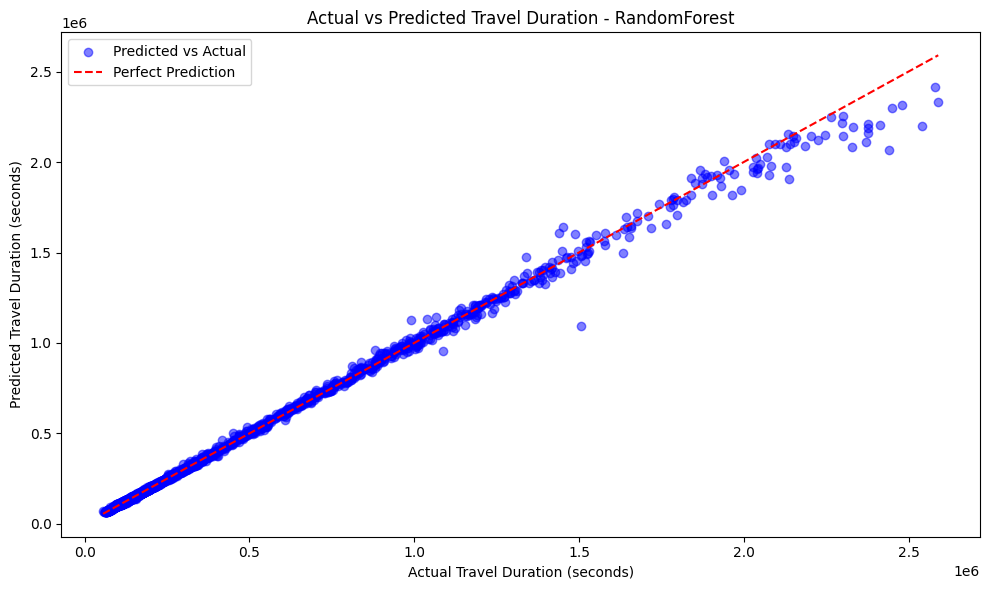

In [13]:
# Plotting Actual vs Predicted Values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.5, label='Predicted vs Actual')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', label='Perfect Prediction')
plt.title('Actual vs Predicted Travel Duration - RandomForest')
plt.xlabel('Actual Travel Duration (seconds)')
plt.ylabel('Predicted Travel Duration (seconds)')
plt.legend()
plt.tight_layout()
plt.show()

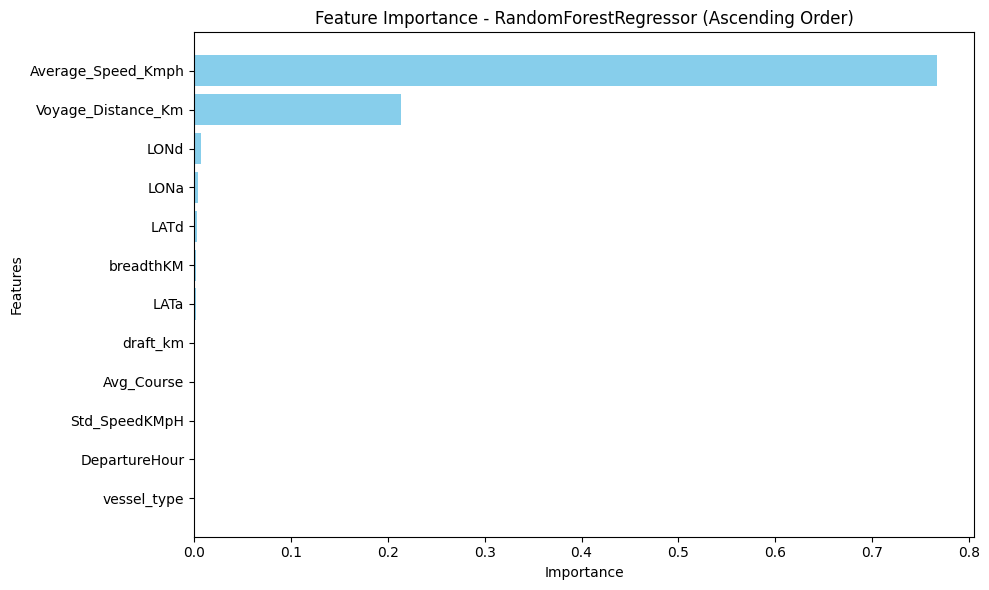

In [21]:
import matplotlib.pyplot as plt
import pandas as pd

# Feature Importance Calculation
best_rf = bayes_search.best_estimator_  # Get the best Random Forest model
feature_importances = best_rf.feature_importances_
features = X.columns
importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=True)

# Plotting Feature Importance with Swapped Axes (Horizontal Bars)
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')  # Use barh for horizontal bars
plt.title('Feature Importance - RandomForestRegressor (Ascending Order)')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.tight_layout()
plt.show()